In [3]:
%pip install seaborn scikit-learn

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'd:\\Program Files\\Pyhton 3.12.10\\Lib\\site-packages\\sklearn\\_cyutility.cp312-win_amd64.pyd'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ------------- -------------------------- 2.6/8.0 MB 13.7 MB/s eta 0:00:01
   ----------------------- ---------------- 4.7/8.0 MB 11.4 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.0 MB 11.0 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 10.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ---------- ----------------------------- 2.6/9.7 MB 12.6 MB/s eta 0:00:01
   ------------------- -------------------- 4.7/9.7 MB 11.4 MB/s eta 0:00:01
   --------------------------- ------------ 6.8/9.7 MB 10.8 MB/s eta 0:00:01
   ----------------------------------- ---- 8.7/9.7 MB 10.5 MB/s eta 0:00:01
   ---------------------------------------- 9.7/9.7 MB 10.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   -- ------------------------------------- 1.8/36.5 MB 9.1 MB/s eta 0:00:04
   ---- --------------


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. Tentukan Path
base_dir = "./DATASET/real_vs_fake/real-vs-fake"

# 2. Transformasi untuk Evaluasi (Sama dengan Validasi)
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 3. Load Dataset TEST
# Pastikan folder 'test' ada di path tersebut
test_dataset = datasets.ImageFolder(os.path.join(base_dir, 'test'), test_transforms)

# 4. Buat DataLoader untuk Test
# Kita masukkan ke dictionary agar kodingan evaluasi di bawahnya tidak error
dataloaders = {
    'test': DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)
}

print(f"✅ Data Loader TEST Berhasil Dibuat!")
print(f"Total Gambar Uji: {len(test_dataset):,}")

✅ Data Loader TEST Berhasil Dibuat!
Total Gambar Uji: 20,000


In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import timm

# 1. Load Model yang Paling Bagus Tadi
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = timm.create_model('mobilenetv4_conv_medium', pretrained=False, num_classes=2)
model.load_state_dict(torch.load('checkpoints/best_mobilenetv4_model.pth'))
model = model.to(device)
model.eval()

print("✅ Model terbaik berhasil dimuat untuk evaluasi!")

✅ Model terbaik berhasil dimuat untuk evaluasi!


Sedang mengevaluasi data test... (Mohon tunggu)


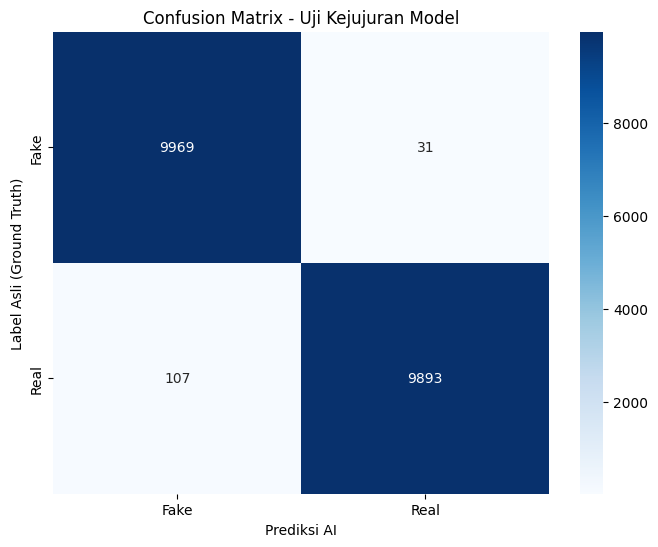


--- Laporan Klasifikasi ---
              precision    recall  f1-score   support

        Fake       0.99      1.00      0.99     10000
        Real       1.00      0.99      0.99     10000

    accuracy                           0.99     20000
   macro avg       0.99      0.99      0.99     20000
weighted avg       0.99      0.99      0.99     20000



In [11]:
all_preds = []
all_labels = []

print("Sedang mengevaluasi data test... (Mohon tunggu)")
with torch.no_grad():
    for inputs, labels in dataloaders['test']: # Gunakan dataloader test
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 3. Tampilkan Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Prediksi AI')
plt.ylabel('Label Asli (Ground Truth)')
plt.title('Confusion Matrix - Uji Kejujuran Model')
plt.show()

print("\n--- Laporan Klasifikasi ---")
print(classification_report(all_labels, all_preds, target_names=['Fake', 'Real']))